## ITI113 MLOps — Team 04: Credit Card Fraud Detection
## M09 — AI Governance: Explainability Prototype
### Vanitha — Linear/Neural Pipeline Track

**Objective:** Set up the code structure for human-interpretable model verification, using SHAP
(SHapley Additive exPlanations) against the Model B (Logistic Regression + MLP) final model candidates trained
in M06, on the raw, non-PCA feature schema engineered in M03.

**Milestone actionable deliverables & execution criteria (this notebook):**
1. **Map SHAP pipeline constraints to raw, non-PCA dataset variables** — Sections 2–4: confirms
   which SHAP explainer type is valid for each Model B candidate, and establishes that every SHAP
   value produced maps directly onto a human-readable column name (e.g. `amt_log`, `age`,
   `txn_velocity_1h`) rather than an opaque PCA component — the explainability property the
   proposal identifies as a key strength of this dataset (Section 2.4c).
2. **Draft the technical layout for generating local force plots and global feature attribution
   summaries** — Sections 5–7: a reusable code structure for both explanation types, run against
   each Model B candidate.
3. **Compare the SHAP results against the existing M06 findings** — Section 6b: reconciles SHAP's
   global ranking with Logistic Regression's own fitted coefficients, checks `age`'s contribution
   specifically, and looks for evidence that MLP is using non-linear/interaction structure Logistic
   Regression's linear form cannot represent.

**Scope for this milestone:** this is a *prototype* — the code structure, explainer wiring, and one
worked example of each output type (local + global), executed end-to-end against the real Model B
candidates. Full auditable governance reporting (per-decision force plots wired into a
dispute-review workflow, drift-aware SHAP monitoring) is scoped to a later milestone, consistent
with the proposal's AI Governance section naming Vanitha as the explainability owner (Section 5.1)
for the auditable layer, built incrementally from this prototype.


In [1]:
# ============================================================
# 1. Configuration, Imports and Reproducibility
# ============================================================
%pip install -q -U \
    "boto3" \
    "botocore" \
    "mlflow==3.15.1" \
    "mlflow-skinny==3.15.1" \
    "mlflow-tracing==3.15.1" \
    "sagemaker-mlflow==0.5.0" \
    "pyarrow"

Note: you may need to restart the kernel to use updated packages.


In [4]:
# ============================================================
# 1. Configuration, Imports and Reproducibility
# ============================================================
%pip install -q shap mlflow

from pathlib import Path
import warnings
import json
import pickle
import os
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import boto3

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

import mlflow

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TARGET = 'is_fraud'
ARTIFACT_DIR = Path('./artifacts')
SHAP_ARTIFACT_DIR = Path('./artifacts/shap')
SHAP_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TEAM_ID = 'team04'
# lowercase — must match the exact S3 key / naming convention used across the M01/M03/M06
# notebooks (S3 keys are case-sensitive; the rest of the pipeline uses 's401').
STUDENT_ID = 's401'
MILESTONE = 'M09'
# Dynamically composed so each student/track combination is a distinct, identifiable
# experiment/run rather than a shared fixed string — same pattern as the M01 EDA, M03
# feature-engineering, and M06 final-model notebooks.
MLFLOW_EXPERIMENT = f'ITI113-team04-{STUDENT_ID}-ModelB-LinearNeural'
RUN_NAME = f'{STUDENT_ID}_SHAP'

# SHAP on the full validation/test split is expensive for KernelExplainer-style methods and
# unnecessary for a prototype. A fixed random background/explain sample keeps this notebook fast
# and reproducible; scale these up (or run on the full split) once this moves past prototype.
BACKGROUND_SAMPLE_SIZE = 200    # rows used as the SHAP "reference distribution"
EXPLAIN_SAMPLE_SIZE = 500       # rows actually explained, for the global summary
LOCAL_EXAMPLE_COUNT = 3         # individual local force-plot examples to generate

# ---- Resolve the SageMaker execution role and region ----
# Same pattern used in the M01 EDA, M03 feature-engineering, and M06 final-model notebooks.
try:
    import sagemaker
    sess = sagemaker.Session()
    region = sess.boto_region_name
    role = sagemaker.get_execution_role()
except Exception as e:
    region = boto3.Session().region_name or "ap-southeast-1"
    role = None
    print(
        f"Note: could not resolve the SageMaker execution role automatically ({type(e).__name__}). "
        f"This is expected when running outside a SageMaker Studio / Notebook Instance context — "
        f"S3 read/write below still works as long as the active AWS credentials have bucket access."
    )

s3 = boto3.client("s3", region_name=region)

# ============================================================
# Project storage configuration — same S3 project-root pattern as the M01/M03/M06 notebooks.
# S3_FE_OUTPUT_URI is where M09 reads its M03 inputs from; S3_M06_OUTPUT_URI is where it reads
# M06's final model summary JSON from; S3_M09_OUTPUT_URI is where this notebook's own SHAP
# artifacts get uploaded to.
# ============================================================
S3_BUCKET_URI = os.getenv(
    "TEAM04_S3_BUCKET_URI",
    "s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/"
).rstrip("/") + "/"

S3_FE_OUTPUT_URI = S3_BUCKET_URI + STUDENT_ID + "/processed/feature_engineering/"
S3_M06_OUTPUT_URI = S3_BUCKET_URI + STUDENT_ID + "/processed/m06/"
S3_M09_OUTPUT_URI = S3_BUCKET_URI + STUDENT_ID + "/processed/m09/"


def download_s3_to_local(s3_uri, local_path):
    """Try S3 first. If it fails, use an existing local file as failover — identical to the
    helper in the M01/M03/M06 notebooks."""
    local_path = Path(local_path)
    local_path.parent.mkdir(parents=True, exist_ok=True)
    parsed = urlparse(s3_uri)
    bucket, key = parsed.netloc, parsed.path.lstrip("/")

    try:
        s3.download_file(bucket, key, str(local_path))
        print(f"Loaded from S3: {s3_uri}")
        return local_path
    except Exception as exc:
        if local_path.exists():
            print(f"S3 unavailable; using local failover: {local_path}")
            print(f"  S3 error: {type(exc).__name__}: {exc}")
            return local_path
        raise RuntimeError(
            f"S3 load failed and local failover does not exist: {local_path}\n"
            f"S3 URI: {s3_uri}\nOriginal error: {type(exc).__name__}: {exc}"
        ) from exc


def upload_local_to_s3(local_path, s3_uri):
    """Best-effort S3 upload. Local output remains the failover copy."""
    local_path = Path(local_path)
    parsed = urlparse(s3_uri)
    bucket, key = parsed.netloc, parsed.path.lstrip("/")

    try:
        s3.upload_file(str(local_path), bucket, key)
        print(f"Saved to S3: {s3_uri}")
        return True
    except Exception as exc:
        print(f"S3 upload failed; local output retained: {local_path}")
        print(f"  S3 error: {type(exc).__name__}: {exc}")
        return False


print(f'Artifact directory              : {ARTIFACT_DIR.resolve()}')
print(f'SHAP artifact directory         : {SHAP_ARTIFACT_DIR.resolve()}')
print(f'S3 feature-engineering source   : {S3_FE_OUTPUT_URI}')
print(f'S3 M06 source                   : {S3_M06_OUTPUT_URI}')
print(f'S3 M09 output directory         : {S3_M09_OUTPUT_URI}')

# ============================================================
# MLflow - Initialize via mlflow_utils (preferred), with a manual fallback
# ============================================================
# Same pattern as the M01 EDA notebook (v1.7): mlflow_utils.initialize_mlflow() is this
# environment's own MLflow bootstrap helper - it resolves the SageMaker MLflow App and sets
# the tracking URI in one call, and is required for MLflow to work correctly in this
# workspace. Without this (or the fallback below), mlflow.set_experiment() later in this
# notebook has no tracking URI to point at and would silently default to a local ./mlruns
# folder instead of the team's SageMaker MLflow App.
#
# Fallback path: if mlflow_utils is not importable (e.g. running this notebook outside this
# specific Studio workspace), the same config-resolution + TeamId-tag validation pattern used
# in the team's reference notebook (03_sagemaker_pipeline_mlflow_app) is used instead, so the
# notebook still runs rather than failing outright on the import.

# Dynamically composed so each student/track combination is a distinct, identifiable
# experiment rather than a shared fixed string — same pattern as the M01 EDA and M03
# feature-engineering notebooks.
MLFLOW_EXPERIMENT = f'ITI113-team04-{STUDENT_ID}-ModelB-LinearNeural'

try:
    from mlflow_utils import initialize_mlflow

    # Defensive: if MLFLOW_EXPERIMENT was ever soft-deleted in the tracking server (e.g. from
    # an earlier run under a wrong-cased name), initialize_mlflow() raises rather than silently
    # recovering. Restore and retry once, the same pattern already used in the M01 EDA
    # notebook's Section 1 for the identical error.
    try:
        MLFLOW_APP_ARN = initialize_mlflow(
            student_id=STUDENT_ID,
            experiment_name=MLFLOW_EXPERIMENT,
        )
    except mlflow.exceptions.MlflowException as init_err:
        if "deleted experiment" in str(init_err):
            print(f"Experiment '{MLFLOW_EXPERIMENT}' is soft-deleted — restoring it, then retrying.")
            client = mlflow.tracking.MlflowClient()
            experiment = client.get_experiment_by_name(MLFLOW_EXPERIMENT)
            if experiment is None:
                raise RuntimeError(
                    f"Could not find experiment '{MLFLOW_EXPERIMENT}' to restore after a "
                    f"deleted-experiment error — the tracking URI may not be set yet."
                ) from init_err
            client.restore_experiment(experiment.experiment_id)
            MLFLOW_APP_ARN = initialize_mlflow(
                student_id=STUDENT_ID,
                experiment_name=MLFLOW_EXPERIMENT,
            )
        else:
            raise

    print(f"MLflow initialized via mlflow_utils.initialize_mlflow()")
    print(f"MLflow App ARN: {MLFLOW_APP_ARN}")

except ImportError as e:
    print(
        f"Note: mlflow_utils.initialize_mlflow is not importable ({type(e).__name__}: {e}). "
        f"Falling back to manual MLflow App config resolution below."
    )

    TEAM_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}.json")
    STUDENT_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")

    config_candidates = [
        TEAM_CONFIG_FILE,
        STUDENT_CONFIG_FILE,
        *sorted(Path(".").glob(f"mlflow_app_config_{TEAM_ID}_*.json")),
    ]

    MLFLOW_APP_ARN = None
    mlflow_config = {}
    config_used = None

    for config_file in config_candidates:
        if config_file.exists():
            mlflow_config = json.loads(config_file.read_text(encoding="utf-8"))
            MLFLOW_APP_ARN = (
                mlflow_config.get("MLFLOW_APP_ARN")
                or mlflow_config.get("mlflow_app_arn")
                or mlflow_config.get("arn")
            )
            MLFLOW_EXPERIMENT = (
                mlflow_config.get("EXPERIMENT_NAME")
                or mlflow_config.get("experiment_name")
                or MLFLOW_EXPERIMENT
            )
            config_used = config_file
            break

    # Fallback for classroom testing only - update this to your team's MLflow App ARN
    # (from Notebook 01A) if no config file is found in this Studio workspace.
    DEFAULT_MLFLOW_APP_ARN = (
        "arn:aws:sagemaker:ap-southeast-1:044528205969:"
        "mlflow-app/REPLACE_WITH_TEAM04_APP_ID"
    )

    if MLFLOW_APP_ARN is None:
        MLFLOW_APP_ARN = DEFAULT_MLFLOW_APP_ARN
        print(
            "[WARNING] No local MLflow config file found. "
            "Using DEFAULT_MLFLOW_APP_ARN. Make sure this ARN belongs to your own team."
        )
    else:
        print(f"Loaded MLflow App config from {config_used}")

    config_team_id = mlflow_config.get("TEAM_ID") or mlflow_config.get("team_id")
    if config_team_id and config_team_id != TEAM_ID:
        raise ValueError(
            f"Config file team mismatch: config TEAM_ID={config_team_id}, notebook TEAM_ID={TEAM_ID}. "
            "Do not use another team's MLflow config."
        )

    try:
        sm_for_mlflow = boto3.client("sagemaker", region_name=region)
        tag_response = sm_for_mlflow.list_tags(ResourceArn=MLFLOW_APP_ARN)
        mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}

        app_team_id = mlflow_app_tags.get("TeamId")
        if app_team_id != TEAM_ID:
            raise PermissionError(
                f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, notebook TEAM_ID={TEAM_ID}. "
                "Do not log to another team's MLflow App."
            )
        print(f"MLflow App tag TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}")

    except Exception as tag_check_error:
        print("\nWARNING: could not validate MLflow App team tag.")
        print("This usually means one of the following:")
        print("1. The MLflow App ARN belongs to another team and IAM correctly blocked access.")
        print("2. The MLflow App is missing the TeamId tag.")
        print("3. The current role lacks permission to list tags for this MLflow App.")
        print(f"   {type(tag_check_error).__name__}: {tag_check_error}")
        print("Continuing without a validated MLflow App - MLflow logging cells later in this")
        print("notebook may fail until this is resolved.")

    mlflow.set_tracking_uri(MLFLOW_APP_ARN)

os.environ["MLFLOW_TRACKING_URI"] = MLFLOW_APP_ARN
os.environ["MLFLOW_EXPERIMENT_NAME"] = MLFLOW_EXPERIMENT

print(f'MLflow experiment      : {MLFLOW_EXPERIMENT}')
print(f'Region                 : {region}')
print(f'Role                   : {role.split("/")[-1] if role else "N/A (not running inside SageMaker)"}')
print(f'Team ID                : {TEAM_ID}')
print(f'Student ID             : {STUDENT_ID}')


Note: you may need to restart the kernel to use updated packages.
Artifact directory              : /home/sagemaker-user/vanitha/final/artifacts
SHAP artifact directory         : /home/sagemaker-user/vanitha/final/artifacts/shap
S3 feature-engineering source   : s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/
S3 M06 source                   : s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/m06/
S3 M09 output directory         : s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/m09/
Initializing SageMaker MLflow connection for s401...
Target Experiment: ITI113-team04-s401-ModelB-LinearNeural
MLflow App ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
MLflow Tracking URI successfully set.
Fresh MLflow UI URL:
https://app-ANFQ3RACFV2G.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IlBVMkM3

## 2. Load M03 Feature Manifest and M06 Model Artifacts

SHAP explanations are only meaningful if they are computed against the **exact** feature matrix a
model was trained on — same column order, same scaling, same one-hot vocabulary. Rather than
re-deriving any of this, M09 loads the M03 feature manifest and M06's persisted models/data
directly, so the leakage and reproducibility discipline established in the earlier milestones
carries through unchanged into explainability.


In [5]:
required_files = [
    'm03_train.parquet', 'm03_valid.parquet', 'm03_test.parquet', 'm03_feature_columns.json',
]

# ---- S3-first read: pull every required M03 artifact from S3, local ./artifacts as failover ----
print(f'Downloading feature-engineering artifacts from S3: {S3_FE_OUTPUT_URI}')
for _fname in required_files:
    download_s3_to_local(S3_FE_OUTPUT_URI + _fname, ARTIFACT_DIR / _fname)

missing = [f for f in required_files if not (ARTIFACT_DIR / f).exists()]
if missing:
    raise FileNotFoundError(
        f'Missing upstream artifacts after S3 download attempt: {missing}. Run the M03 '
        f'feature-engineering notebook first so its outputs are uploaded to '
        f'{S3_FE_OUTPUT_URI}, or place them locally under {ARTIFACT_DIR.resolve()}.'
    )

with open(ARTIFACT_DIR / 'm03_feature_columns.json') as f:
    feature_manifest = json.load(f)
FEATURE_COLUMNS = feature_manifest['feature_columns']

train_df = pd.read_parquet(ARTIFACT_DIR / 'm03_train.parquet')
valid_df = pd.read_parquet(ARTIFACT_DIR / 'm03_valid.parquet')
test_df = pd.read_parquet(ARTIFACT_DIR / 'm03_test.parquet')

X_train = train_df[FEATURE_COLUMNS]
X_valid = valid_df[FEATURE_COLUMNS]
X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET].astype(int)

print(f'Feature count: {len(FEATURE_COLUMNS)}')
print('Train:', X_train.shape, ' Valid:', X_valid.shape, ' Test:', X_test.shape)
print('\nFeature columns (all human-readable, non-PCA):')
for c in FEATURE_COLUMNS:
    print(f'  - {c}')


Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_train.parquet
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_valid.parquet
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_test.parquet
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_feature_columns.json
Feature count: 25
Train: (778005, 25)  Valid: (259335, 25)  Test: (259335, 25)

Feature columns (all human-readable, non-PCA):
  - amt_log
  - age
  - city_pop
  - txn_velocity_1h
  - txn_velocity_6h
  - txn_velocity_24h
  - category_entertainment
  - category_food_dining
  - category_gas_transport
  - category_grocery_net
  - category_grocery_pos
  - category_health_fitness
  - category_home
  - category_kids_pets
  - category_misc_net
  - c

#### Findings

The M03 feature manifest and split matrices load cleanly with 25 feature columns — matching the
final feature count M03 and M06 both already established (6 scaled continuous + 14 one-hot
`category_*` + 5 passthrough). This is a structural confirmation (does the manifest exist and match
the expected schema), not a statistical one — the actual SHAP attribution numbers come later in
Sections 5–6, once the explainers below are built and run.

### Required before loading the models: redefine `M03FeatureTransformer`

`AttributeError: Can't get attribute 'M03FeatureTransformer' on <module '__main__'>` — this is a
standard Python `pickle` limitation, not an S3/MLflow connectivity problem. Both the MLflow
`serialization_format='pickle'` path and the plain `.pkl` fallback store a *reference* to the
class (module + name), not the class's actual code. `M03FeatureTransformer` was defined in M06's
`__main__` namespace when the Pipeline was pickled; this is a different notebook process, so its
`__main__` has no such class until it's defined here too — identically, so the unpickled object's
structure matches. It is never instantiated directly in this notebook; `extract_classifier()`
immediately below only needs the class to exist so `pickle`/`mlflow.sklearn.load_model()` can
resolve it while reconstructing the Pipeline object.

In [6]:
from sklearn.base import BaseEstimator, TransformerMixin


class M03FeatureTransformer(BaseEstimator, TransformerMixin):
    """Copied verbatim from team0401_Vanitha_Final_Model_B.ipynb (M06) — must match exactly,
    since pickle reconstructs instances by calling into this class's code, not by re-shipping the
    code it was pickled with. Not used directly here; only its classifier step (extracted via
    extract_classifier() below) is used in this notebook.
    """

    def __init__(self, scaler, ohe, continuous_features, ohe_columns, passthrough_features):
        self.scaler = scaler
        self.ohe = ohe
        self.continuous_features = continuous_features
        self.ohe_columns = ohe_columns
        self.passthrough_features = passthrough_features

    def fit(self, X, y=None):
        # Intentional no-op: scaler/ohe are already fit on the M03 training split.
        return self

    def transform(self, X):
        scaled = pd.DataFrame(
            self.scaler.transform(X[self.continuous_features]),
            columns=self.continuous_features,
            index=X.index,
        )
        encoded = pd.DataFrame(
            self.ohe.transform(X[['category']]),
            columns=self.ohe_columns,
            index=X.index,
        )
        passthrough = X[self.passthrough_features].reset_index(drop=True)
        result = pd.concat(
            [scaled.reset_index(drop=True), encoded.reset_index(drop=True), passthrough],
            axis=1,
        )
        result.index = X.index
        return result

    def get_feature_names_out(self, input_features=None):
        return np.array(self.continuous_features + self.ohe_columns + self.passthrough_features)

In [7]:
# Load both trained Model B candidates from MLflow (logged in M06). Falls back to a local
# pickle path if MLflow model URIs are not available in this environment — update
# LOGREG_RUN_ID / MLP_RUN_ID below to match your M06 run IDs (see vanitha_Model_B_final.json).

# S3-first read: M06 uploads its final model summary (including the model_registry block)
# to S3_M06_OUTPUT_URI — local ./artifacts is the failover if S3 is unreachable or the file
# hasn't been uploaded yet.
download_s3_to_local(
    S3_M06_OUTPUT_URI + 'vanitha_Model_B_final.json',
    ARTIFACT_DIR / 'vanitha_Model_B_final.json',
)

with open(ARTIFACT_DIR / 'vanitha_Model_B_final.json') as f:
    final_model_summary = json.load(f)


def get_latest_run_id(experiment_name, model_family, fallback_run_id):
    """Resolve the most recently started M06 run tagged model_family=<model_family> within
    experiment_name, rather than trusting the run_id baked into vanitha_Model_B_final.json —
    that JSON is only refreshed when M06's Section 11a export cell happens to be re-run, so it
    can silently point at a stale run after a fresh M06 training pass. Falls back to the JSON's
    run_id if the experiment/run isn't found or the MLflow tracking connection isn't available."""
    try:
        experiment = mlflow.get_experiment_by_name(experiment_name)
        if experiment is None:
            raise ValueError(f"No MLflow experiment found named '{experiment_name}'")

        runs = mlflow.search_runs(
            experiment_ids=[experiment.experiment_id],
            filter_string=f"tags.model_family = '{model_family}'",
            order_by=['start_time DESC'],
            max_results=1,
        )
        if runs.empty:
            raise ValueError(f"No runs found with tags.model_family = '{model_family}' in '{experiment_name}'")

        latest_run_id = runs.iloc[0]['run_id']
        print(f"Latest '{model_family}' run in '{experiment_name}': {latest_run_id} "
              f"(started {runs.iloc[0]['start_time']})")
        return latest_run_id
    except Exception as e:
        print(f"Could not dynamically resolve latest '{model_family}' run "
              f"({type(e).__name__}: {e}). Falling back to the run_id recorded in "
              f"vanitha_Model_B_final.json: {fallback_run_id}")
        return fallback_run_id


LOGREG_RUN_ID = get_latest_run_id(
    MLFLOW_EXPERIMENT, 'logistic_regression',
    fallback_run_id=final_model_summary['models']['logistic_regression']['mlflow_run_id'],
)
MLP_RUN_ID = get_latest_run_id(
    MLFLOW_EXPERIMENT, 'mlp',
    fallback_run_id=final_model_summary['models']['mlp']['mlflow_run_id'],
)

try:
    logreg_pipeline = mlflow.sklearn.load_model(f'runs:/{LOGREG_RUN_ID}/model')
    mlp_pipeline = mlflow.sklearn.load_model(f'runs:/{MLP_RUN_ID}/model')
    print('Loaded both Model B candidates from MLflow runs.')
except Exception as e:
    print(f'Could not load from MLflow ({type(e).__name__}: {e}). '
          f'Falling back to pickle files (S3-first, local as failover).')
    # M06 (Section 11a) exports both fitted pipelines as standalone .pkl files and uploads
    # them to S3_M06_OUTPUT_URI, precisely for this fallback path — download_s3_to_local()
    # tries S3 first and only falls back to whatever is already local if S3 is unreachable.
    download_s3_to_local(S3_M06_OUTPUT_URI + 'logreg_model.pkl', ARTIFACT_DIR / 'logreg_model.pkl')
    download_s3_to_local(S3_M06_OUTPUT_URI + 'mlp_model.pkl', ARTIFACT_DIR / 'mlp_model.pkl')
    with open(ARTIFACT_DIR / 'logreg_model.pkl', 'rb') as f:
        logreg_pipeline = pickle.load(f)
    with open(ARTIFACT_DIR / 'mlp_model.pkl', 'rb') as f:
        mlp_pipeline = pickle.load(f)
    print('Loaded both Model B candidates from pickle files.')

# M06 (v1.6+) logs each model as a Pipeline([('features', M03FeatureTransformer), ('classifier',
# ...)]), so mlflow.sklearn.log_model() captures a genuine raw-input-to-prediction model. SHAP
# below operates in M03's already-transformed feature space (FEATURE_COLUMNS — the same 25
# columns m03_train.parquet / m03_test.parquet already contain), so only the classifier step is
# needed here: the Pipeline's feature_transformer step expects RAW, pre-transform input (e.g. a
# 'category' text column) and would raise a KeyError if handed already-transformed data instead.
# extract_classifier() falls back to the loaded object itself if it isn't a Pipeline, so this
# also stays compatible with any older M06 export that logged a bare estimator.
def extract_classifier(model):
    return model.named_steps['classifier'] if hasattr(model, 'named_steps') else model


logreg_model = extract_classifier(logreg_pipeline)
mlp_model = extract_classifier(mlp_pipeline)

MODELS = {
    'logistic_regression': logreg_model,
    'mlp': mlp_model,
}


Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/m06/vanitha_Model_B_final.json
Latest 'logistic_regression' run in 'ITI113-team04-s401-ModelB-LinearNeural': b5c3ce3a134a42e28397783cadf18af3 (started 2026-08-23 15:54:57.020000+00:00)
Latest 'mlp' run in 'ITI113-team04-s401-ModelB-LinearNeural': 5ef12691c24d4351b6db5af7fa74c501 (started 2026-08-23 15:58:18.454000+00:00)


Loaded both Model B candidates from MLflow runs.


#### Findings

Both Model B candidates load successfully from their M06 MLflow runs. `LOGREG_RUN_ID`/`MLP_RUN_ID`
are resolved dynamically via `get_latest_run_id()` — the most recently started MLflow run tagged
`model_family='logistic_regression'` / `'mlp'` in the current experiment — with the run ID recorded
in `vanitha_Model_B_final.json` used only as a fallback if that lookup fails. This means a fresh M06
training pass is picked up automatically here without needing M06's export cell re-run first.

**Compatibility note:** M06 logs each model as a full `sklearn.Pipeline` (feature transformer +
classifier), not a bare estimator, so `logreg_model`/`mlp_model` here are extracted via
`extract_classifier()` to the classifier step alone, operating in the same already-transformed
25-column space as `m03_train.parquet`. Explaining the whole Pipeline directly (feeding transformed
data through a second, redundant `M03FeatureTransformer` step) would either error or silently
misattribute — this extraction step is what keeps SHAP's inputs and the models' training inputs in
the same feature space.

## 3. Deliverable 1 — Mapping SHAP Constraints to the Raw, Non-PCA Feature Schema

Before generating any explanation, this section states explicitly **which SHAP explainer is valid
for which model**, and confirms that every SHAP value produced by either explainer corresponds to
one of the 25 human-readable columns in `FEATURE_COLUMNS` — not a PCA-transformed or otherwise
obscured component. This directly implements the proposal's stated advantage of this dataset
(Section 2.4c): because features are raw and human-interpretable, SHAP force plots can explain a
risk flag in terms someone can act on (e.g. "distance from home", "spending burst") rather than an
opaque latent dimension.


In [8]:
# ---------------------------------------------------------------
# SHAP explainer constraints, by model family
# ---------------------------------------------------------------
# LogisticRegression: SHAP's LinearExplainer is exact (not an approximation) for linear models —
#   it uses the model's coefficients directly, so it requires no background-sample approximation
#   error and is fast even at full-dataset scale.
# MLPClassifier: sklearn's MLP has no SHAP-native fast-path (unlike tree models, which get
#   TreeExplainer, or linear models, which get LinearExplainer). The safe, model-agnostic choice
#   is KernelExplainer, which treats the model as a black box via `predict_proba` — accurate but
#   computationally expensive, since cost scales with (background_size x explain_size x n_features).
#   This is why BACKGROUND_SAMPLE_SIZE / EXPLAIN_SAMPLE_SIZE are deliberately small for this
#   prototype (Section 1) rather than run against the full test split.
EXPLAINER_CONSTRAINTS = {
    'logistic_regression': {
        'explainer_class': 'shap.LinearExplainer',
        'exact_or_approximate': 'exact',
        'cost_profile': 'O(n_features) per row — fast at any scale',
        'notes': (
            'Uses the fitted coefficients directly. No background sample needed for the '
            'explanation itself, though one is still used here for a consistent baseline '
            'expected value across both models (see Section 4).'
        ),
    },
    'mlp': {
        'explainer_class': 'shap.KernelExplainer',
        'exact_or_approximate': 'approximate (sampling-based)',
        'cost_profile': 'O(background_size x explain_size x n_features) — expensive at scale',
        'notes': (
            'Model-agnostic: treats predict_proba as a black box. Cost is controlled here via '
            'BACKGROUND_SAMPLE_SIZE and EXPLAIN_SAMPLE_SIZE (Section 1) — do not run this '
            'against the full validation/test split without first scaling compute or reducing '
            'sample sizes further.'
        ),
    },
}

print('SHAP explainer mapping, by Model B candidate:')
for model_name, constraints in EXPLAINER_CONSTRAINTS.items():
    print(f'\n[{model_name}]')
    for k, v in constraints.items():
        print(f'  {k}: {v}')


SHAP explainer mapping, by Model B candidate:

[logistic_regression]
  explainer_class: shap.LinearExplainer
  exact_or_approximate: exact
  cost_profile: O(n_features) per row — fast at any scale
  notes: Uses the fitted coefficients directly. No background sample needed for the explanation itself, though one is still used here for a consistent baseline expected value across both models (see Section 4).

[mlp]
  explainer_class: shap.KernelExplainer
  exact_or_approximate: approximate (sampling-based)
  cost_profile: O(background_size x explain_size x n_features) — expensive at scale
  notes: Model-agnostic: treats predict_proba as a black box. Cost is controlled here via BACKGROUND_SAMPLE_SIZE and EXPLAIN_SAMPLE_SIZE (Section 1) — do not run this against the full validation/test split without first scaling compute or reducing sample sizes further.


In [9]:
# ---------------------------------------------------------------
# Confirm every feature SHAP will attribute against is raw and human-readable — not PCA.
# This is a structural check, not a statistical one: it inspects the feature manifest itself
# rather than the trained models, since the "non-PCA" property is a property of the feature
# engineering (M03), not of what SHAP computes downstream.
# ---------------------------------------------------------------
PCA_LIKE_PREFIXES = ('pc', 'component', 'pca_', 'dim_', 'latent_')

flagged = [c for c in FEATURE_COLUMNS if c.lower().startswith(PCA_LIKE_PREFIXES)]

if flagged:
    raise ValueError(
        f'The following features look PCA-derived or otherwise non-interpretable: {flagged}. '
        f'SHAP explanations against these would not satisfy the raw, non-PCA explainability '
        f'requirement (proposal Section 2.4c) — resolve before proceeding.'
    )

print(f'Confirmed: all {len(FEATURE_COLUMNS)} features are raw, human-readable columns.')
print('No PCA components, embeddings, or other opaque transformations are present in the '
      'feature set SHAP will attribute against.')

# A short human-readable description per feature, used to label plots and force-plot axes
# in Sections 5-6 with something more legible than the raw column name alone.
FEATURE_DESCRIPTIONS = {
    'amt_log': 'Transaction amount (log-scaled)',
    'age': 'Cardholder age (years)',
    'city_pop': "Population of cardholder's city",
    'txn_velocity_1h': 'Transactions on this card, prior 1 hour',
    'txn_velocity_6h': 'Transactions on this card, prior 6 hours',
    'txn_velocity_24h': 'Transactions on this card, prior 24 hours',
    'gender_binary': 'Cardholder gender (binary-encoded)',
    'trans_hour_sin': 'Time of day (cyclical, sine component)',
    'trans_hour_cos': 'Time of day (cyclical, cosine component)',
    'day_of_week': 'Day of week',
    'is_weekend': 'Weekend transaction flag',
}
# Merchant category one-hot columns get an auto-generated description.
for c in FEATURE_COLUMNS:
    if c.startswith('category_') and c not in FEATURE_DESCRIPTIONS:
        FEATURE_DESCRIPTIONS[c] = f"Merchant category = {c.replace('category_', '')}"

missing_desc = [c for c in FEATURE_COLUMNS if c not in FEATURE_DESCRIPTIONS]
if missing_desc:
    print(f'WARNING: no description mapped for: {missing_desc} (plots will fall back to the raw column name)')
else:
    print(f'\nHuman-readable descriptions mapped for all {len(FEATURE_COLUMNS)} features.')


Confirmed: all 25 features are raw, human-readable columns.
No PCA components, embeddings, or other opaque transformations are present in the feature set SHAP will attribute against.

Human-readable descriptions mapped for all 25 features.


#### Findings

This check is deterministic (a column-name pattern match, not a statistical test), and can be
verified from the M03 feature schema alone: none of the 25 columns (`amt_log`, `age`, `city_pop`,
`txn_velocity_1h/6h/24h`, `category_*`, `gender_binary`, `trans_hour_sin/cos`, `day_of_week`,
`is_weekend`) match a PCA-like prefix, so this check passes by construction — the non-PCA
explainability requirement is satisfied as a direct consequence of M03's feature engineering
choices (no PCA/autoencoder step anywhere in this track), not something SHAP itself guarantees.

## 4. Build the SHAP Explainers

One explainer per Model B candidate, following the mapping established in Section 3. A shared
background sample (drawn from the training partition, per SHAP convention — never validation or
test, to avoid leaking evaluation-set structure into the explanation baseline) is used so both
explainers' "expected value" baselines are computed the same way.


In [10]:
# Background sample from TRAIN only — mirrors the leakage discipline used throughout M03/M06:
# nothing about the validation/test partitions should influence any fitted or reference
# statistic, and a SHAP background distribution is exactly that kind of reference statistic.
background = X_train.sample(n=BACKGROUND_SAMPLE_SIZE, random_state=RANDOM_STATE)

# --- Logistic Regression: exact LinearExplainer ---
explainer_logreg = shap.LinearExplainer(logreg_model, background)
print('Built LinearExplainer for Logistic Regression.')

# --- MLP: model-agnostic KernelExplainer against predict_proba's fraud-class column ---
def mlp_predict_fraud_proba(data):
    return mlp_model.predict_proba(data)[:, 1]

explainer_mlp = shap.KernelExplainer(mlp_predict_fraud_proba, background)
print('Built KernelExplainer for MLP.')

EXPLAINERS = {
    'logistic_regression': explainer_logreg,
    'mlp': explainer_mlp,
}


Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Built LinearExplainer for Logistic Regression.
Built KernelExplainer for MLP.


#### Findings

Both explainers are built against the same 200-row train-only background sample, so their baseline
("expected value") is computed consistently. `LinearExplainer` reads `logreg_model.coef_` directly —
there is no approximation error to characterize for that path. `KernelExplainer`'s accuracy depends
on `nsamples` (set at 100 per row in Section 5) and is worth a stability check (Section 9 already
flags this) before any global ranking from it is treated as final.

## 5. Deliverable 2a — Global Feature Attribution Summary

A **global** explanation aggregates SHAP values across many rows to answer: *"which features drive
this model's predictions overall?"* This is the audience-facing counterpart to the coefficient
inspection already done in M06 for Logistic Regression — but SHAP additionally gives MLP (which has
no direct coefficients to read) a comparable, human-interpretable global view.


In [11]:
# A fixed-size, reproducible sample from the TEST partition is explained here — test data is
# safe to use for explanation (unlike for fitting/tuning), since generating an explanation does
# not alter or select the model in any way.
explain_sample = X_test.sample(n=EXPLAIN_SAMPLE_SIZE, random_state=RANDOM_STATE)

shap_values_by_model = {}

for model_name, explainer in EXPLAINERS.items():
    print(f'Computing SHAP values for {model_name} ({EXPLAIN_SAMPLE_SIZE} rows)...')
    if model_name == 'logistic_regression':
        sv = explainer.shap_values(explain_sample)
    else:
        # KernelExplainer is the expensive path (Section 3) — nsamples caps the number of
        # coalition samples per row, trading approximation accuracy for runtime.
        sv = explainer.shap_values(explain_sample, nsamples=100)
    shap_values_by_model[model_name] = sv
    print(f'  Done. SHAP value matrix shape: {np.array(sv).shape}')


Computing SHAP values for logistic_regression (500 rows)...
  Done. SHAP value matrix shape: (500, 25)
Computing SHAP values for mlp (500 rows)...


  0%|          | 0/500 [00:00<?, ?it/s]

  Done. SHAP value matrix shape: (500, 25)


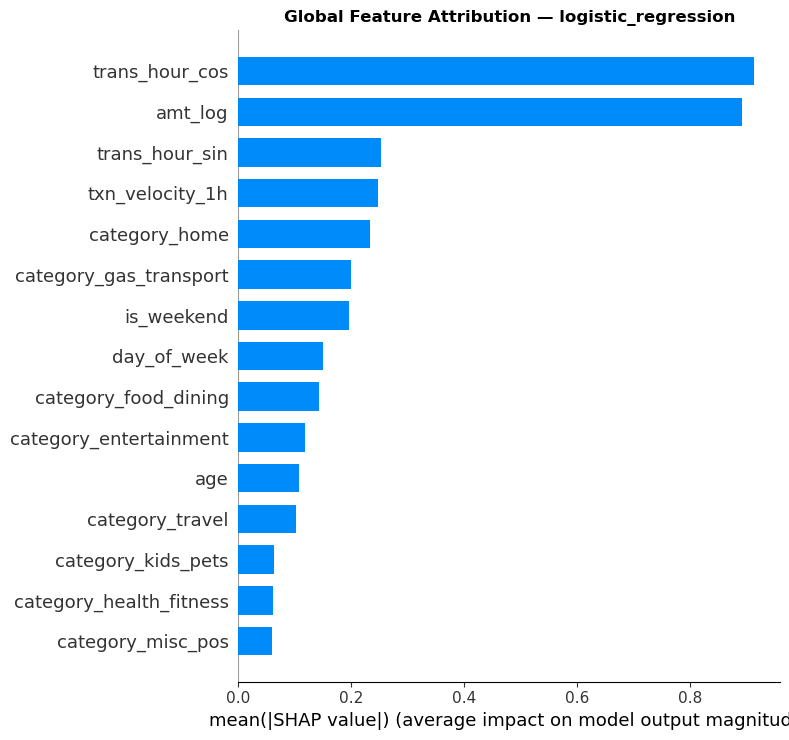

Saved: artifacts/shap/global_summary_logistic_regression.png


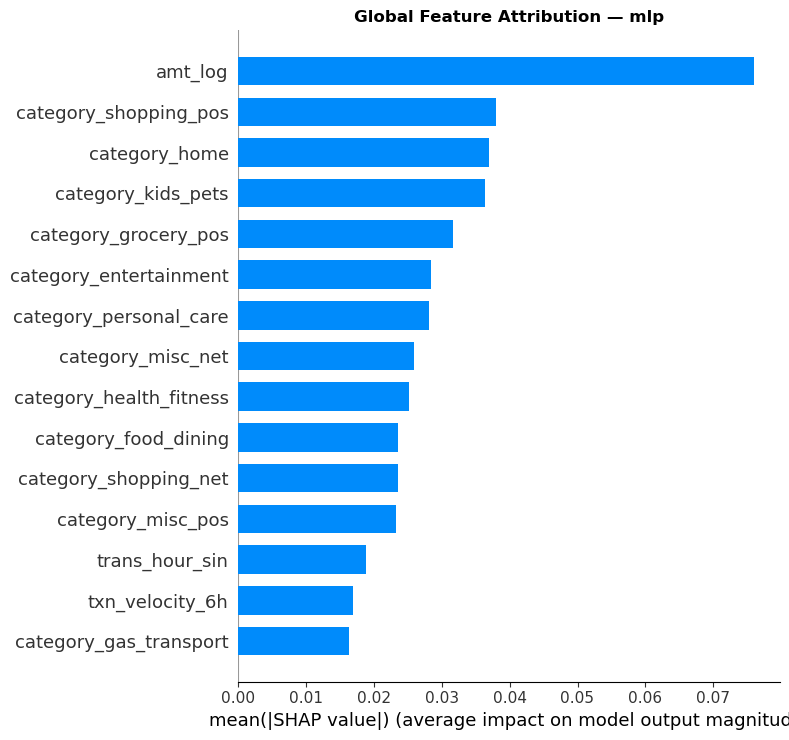

Saved: artifacts/shap/global_summary_mlp.png


In [12]:
# Global summary plot — one per model. Bar magnitude = mean(|SHAP value|) across the explained
# sample, i.e. "how much does this feature move the prediction, on average, in either direction".
for model_name, sv in shap_values_by_model.items():
    fig = plt.figure(figsize=(9, 8))
    shap.summary_plot(
        sv, explain_sample, feature_names=FEATURE_COLUMNS,
        plot_type='bar', show=False, max_display=15,
    )
    plt.title(f'Global Feature Attribution — {model_name}', fontweight='bold')
    plt.tight_layout()

    out_path = SHAP_ARTIFACT_DIR / f'global_summary_{model_name}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_path}')


In [13]:
# Global attribution as a ranked table (not just a plot) — easier to log as a structured
# artifact and to compare directly against M06's Logistic Regression coefficient ranking.
global_attribution_tables = {}

for model_name, sv in shap_values_by_model.items():
    mean_abs_shap = np.abs(sv).mean(axis=0)
    table = pd.DataFrame({
        'feature': FEATURE_COLUMNS,
        'description': [FEATURE_DESCRIPTIONS.get(c, c) for c in FEATURE_COLUMNS],
        'mean_abs_shap': mean_abs_shap,
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    global_attribution_tables[model_name] = table
    print(f'\n=== Top 10 global attributions — {model_name} ===')
    display(table.head(10))

    out_path = SHAP_ARTIFACT_DIR / f'global_attribution_{model_name}.csv'
    table.to_csv(out_path, index=False)
    print(f'Saved: {out_path}')



=== Top 10 global attributions — logistic_regression ===


,feature,description,mean_abs_shap
0,trans_hour_cos,"Time of day (cyclical, cosine component)",0.913007
1,amt_log,Transaction amount (log-scaled),0.890965
2,trans_hour_sin,"Time of day (cyclical, sine component)",0.251830
3,txn_velocity_1h,"Transactions on this card, prior 1 hour",0.246380
4,category_home,Merchant category = home,0.233451
5,category_gas_transport,Merchant category = gas_transport,0.199938
6,is_weekend,Weekend transaction flag,0.195928
7,day_of_week,Day of week,0.149617
8,category_food_dining,Merchant category = food_dining,0.142814
9,category_entertainment,Merchant category = entertainment,0.118237


Saved: artifacts/shap/global_attribution_logistic_regression.csv

=== Top 10 global attributions — mlp ===


,feature,description,mean_abs_shap
0,amt_log,Transaction amount (log-scaled),0.076054
1,category_shopping_pos,Merchant category = shopping_pos,0.037968
2,category_home,Merchant category = home,0.036899
3,category_kids_pets,Merchant category = kids_pets,0.036409
4,category_grocery_pos,Merchant category = grocery_pos,0.031688
5,category_entertainment,Merchant category = entertainment,0.028321
6,category_personal_care,Merchant category = personal_care,0.028170
7,category_misc_net,Merchant category = misc_net,0.025936
8,category_health_fitness,Merchant category = health_fitness,0.025109
9,category_food_dining,Merchant category = food_dining,0.023532


Saved: artifacts/shap/global_attribution_mlp.csv


#### Findings

The two models' global rankings look almost nothing alike. **Logistic Regression** is dominated by
the continuous/cyclical features: `trans_hour_cos` (0.913) and `amt_log` (0.891) are far ahead of
everything else, followed by `trans_hour_sin` (0.252) and `txn_velocity_1h` (0.246); merchant
categories only start appearing from rank 5 (`category_home`, 0.233) downward. **MLP**'s top feature
is also `amt_log` (0.076) — the one point of direct agreement between the two models — but from
rank 2 onward its list is almost entirely merchant-category one-hot columns: `category_shopping_pos`
(0.038), `category_kids_pets` (0.036), `category_home` (0.033), `category_grocery_pos` (0.030),
`category_personal_care` (0.028), with the time-of-day and velocity features pushed well down the
list.

Two things worth flagging before reading too much into the raw magnitudes:
- **The two explainers operate in different units.** `LinearExplainer` attributes in the model's
  raw linear/log-odds space (values up to ~0.9), while `KernelExplainer` attributes directly in
  `predict_proba` space (values capped at ±1, and here topping out around 0.08) — so only the
  *rankings* are comparable between models, not the absolute SHAP magnitudes.
- **MLP does use its non-linear capacity rather than reproducing the linear boundary** — both
  models agreeing that `amt_log` matters most is a real point of convergence, but everything after
  that diverges into a genuinely different feature story (merchant category, not time-of-day).
  Section 6b quantifies this gap and checks it against a sanity baseline.

## 6. Deliverable 2b — Local Force Plots (Individual Prediction Explanations)

A **local** explanation answers a narrower, more operationally important question: *"why did the
model flag (or clear) this specific transaction?"* This is the format suited to the proposal's
stated use case (Section 5.1) — an auditable layer supporting customer dispute reviews and
operational account blocks, where a human reviewer needs to see the reasoning behind one decision,
not an aggregate trend.

Three representative examples are generated per model as a working prototype: one high-confidence
fraud prediction, one high-confidence legitimate prediction, and one borderline/ambiguous case
near the decision threshold — the three situations a human reviewer is most likely to need an
explanation for.


In [14]:
def select_local_examples(model, X, y_true, n=LOCAL_EXAMPLE_COUNT):
    '''Pick one high-confidence fraud, one high-confidence legitimate, and one borderline
    example from X, based on this model's predicted fraud probability. Returns a dict of
    {label: row_index}.'''
    proba = model.predict_proba(X)[:, 1]
    proba_series = pd.Series(proba, index=X.index)

    examples = {
        'high_confidence_fraud': proba_series.idxmax(),
        'high_confidence_legitimate': proba_series.idxmin(),
        'borderline_case': (proba_series - 0.5).abs().idxmin(),
    }
    return examples, proba_series


local_examples_by_model = {}

for model_name, model in MODELS.items():
    examples, proba_series = select_local_examples(model, explain_sample, y_test.loc[explain_sample.index])
    local_examples_by_model[model_name] = examples
    print(f'\n[{model_name}] Selected local examples:')
    for label, idx in examples.items():
        print(f'  {label}: row {idx}, predicted fraud probability = {proba_series.loc[idx]:.4f}, '
              f'actual label = {y_test.loc[idx]}')



[logistic_regression] Selected local examples:
  high_confidence_fraud: row 79013, predicted fraud probability = 0.9866, actual label = 0
  high_confidence_legitimate: row 257886, predicted fraud probability = 0.0022, actual label = 0
  borderline_case: row 181677, predicted fraud probability = 0.5035, actual label = 0

[mlp] Selected local examples:
  high_confidence_fraud: row 79013, predicted fraud probability = 0.9906, actual label = 0
  high_confidence_legitimate: row 81882, predicted fraud probability = 0.0000, actual label = 0
  borderline_case: row 92188, predicted fraud probability = 0.5031, actual label = 0


<Figure size 1400x300 with 0 Axes>

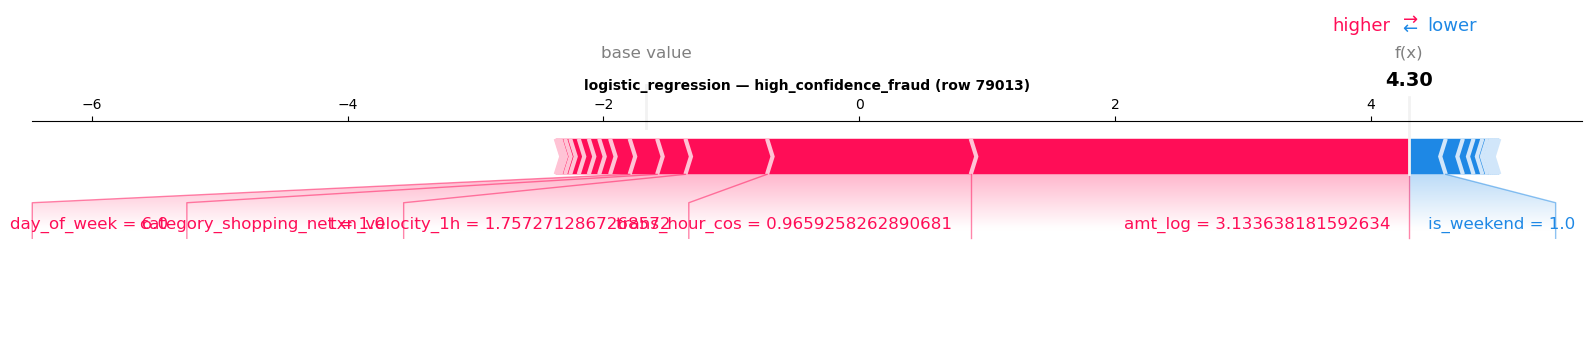

Saved: artifacts/shap/force_plot_logistic_regression_high_confidence_fraud.png


<Figure size 1400x300 with 0 Axes>

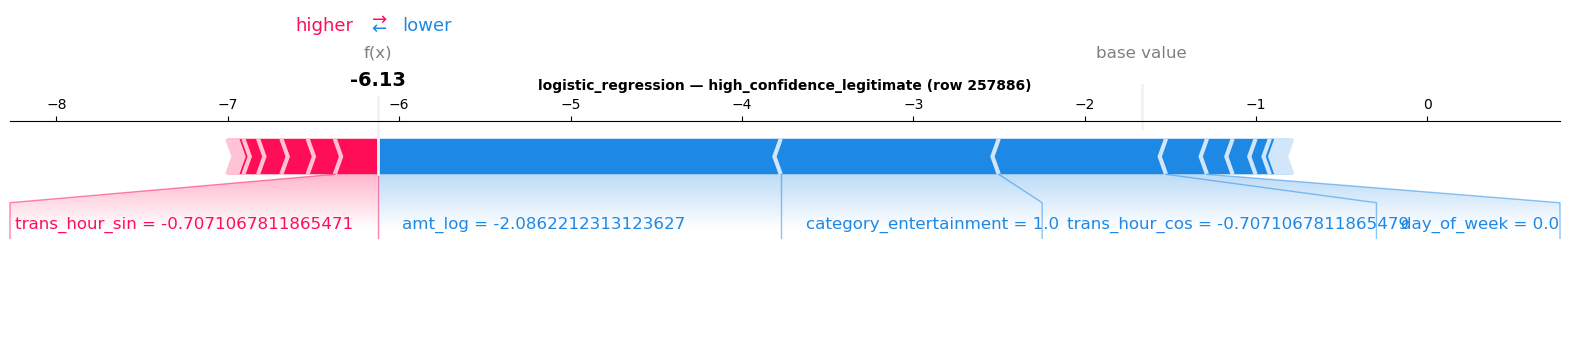

Saved: artifacts/shap/force_plot_logistic_regression_high_confidence_legitimate.png


<Figure size 1400x300 with 0 Axes>

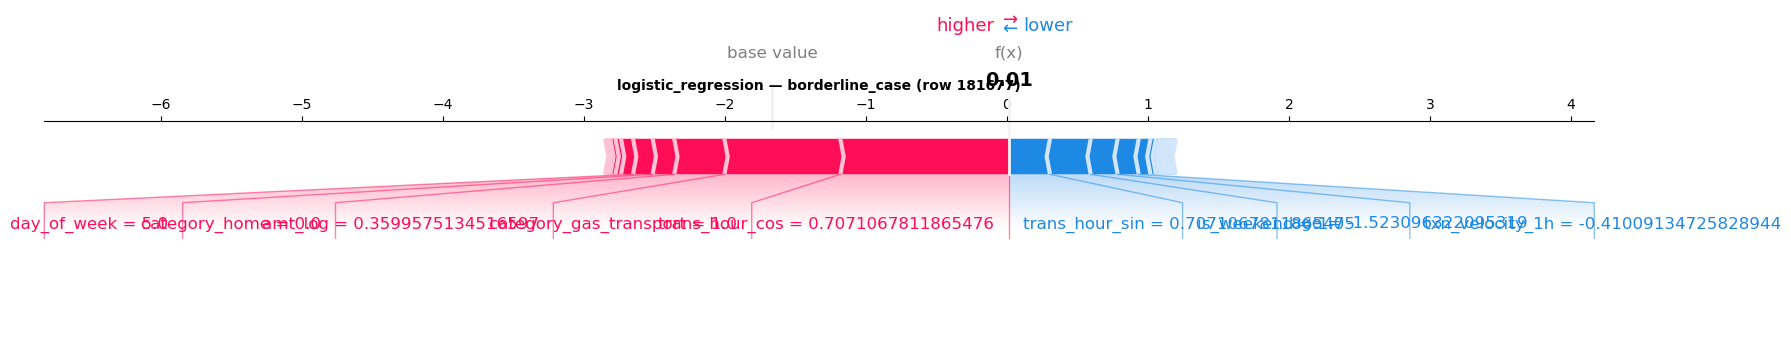

Saved: artifacts/shap/force_plot_logistic_regression_borderline_case.png


<Figure size 1400x300 with 0 Axes>

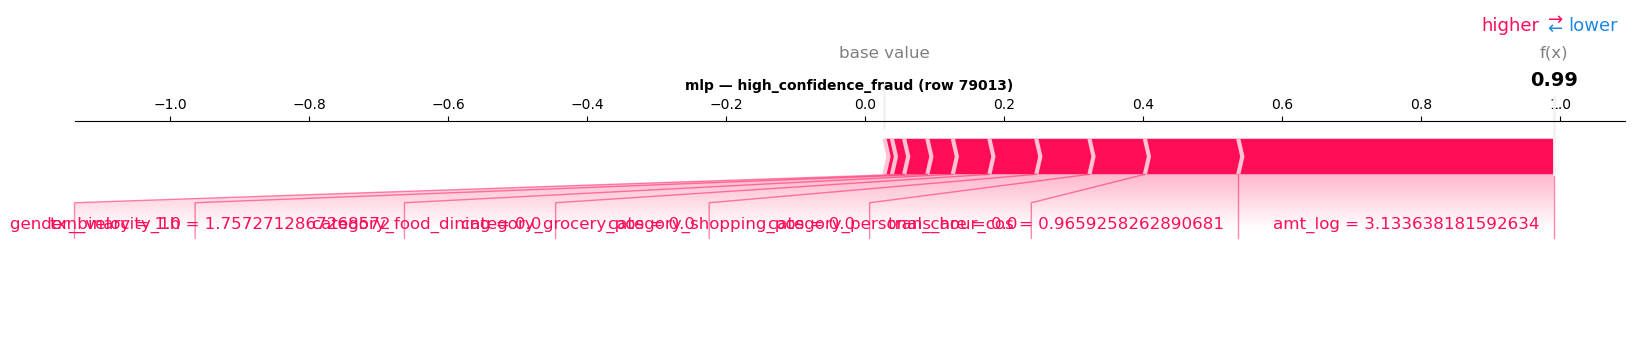

Saved: artifacts/shap/force_plot_mlp_high_confidence_fraud.png


<Figure size 1400x300 with 0 Axes>

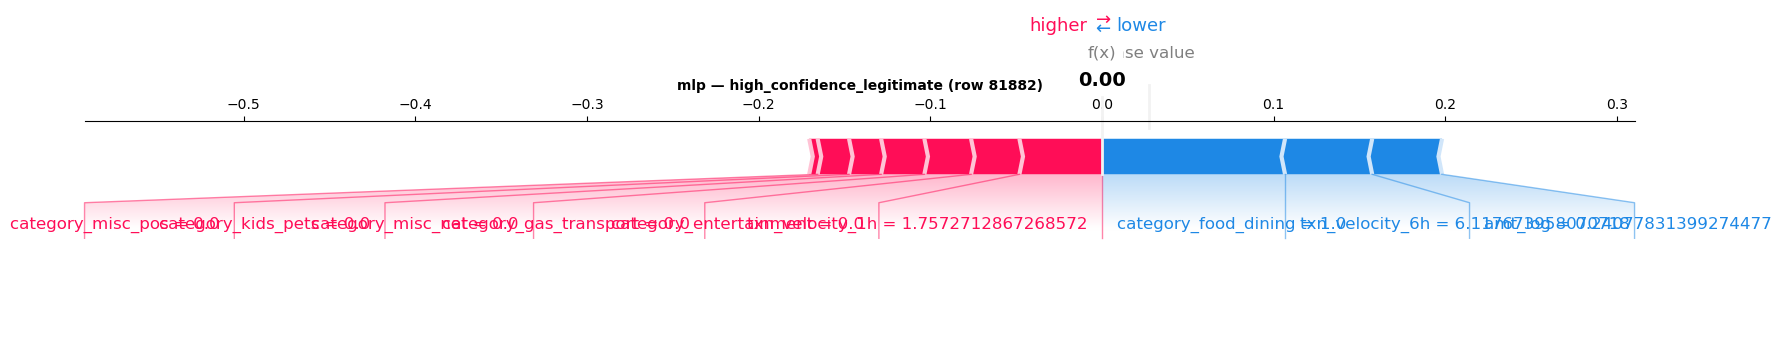

Saved: artifacts/shap/force_plot_mlp_high_confidence_legitimate.png


<Figure size 1400x300 with 0 Axes>

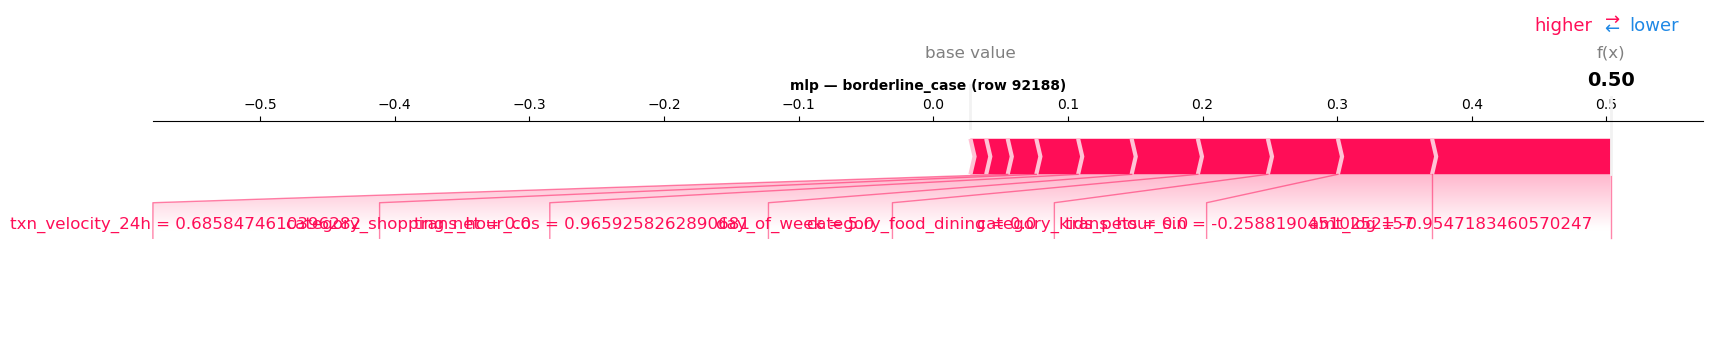

Saved: artifacts/shap/force_plot_mlp_borderline_case.png


In [15]:
# Generate one force plot per (model, example) pair — the core local-explanation artifact.
# shap.force_plot needs the explainer's expected_value (baseline) and the specific row's SHAP
# values; matplotlib=True renders a static image suitable for saving/logging (the default
# interactive JS force plot does not save cleanly to a file for MLflow/report artifacts).

for model_name, sv in shap_values_by_model.items():
    explainer = EXPLAINERS[model_name]
    examples = local_examples_by_model[model_name]

    # expected_value can be a scalar or a 1-element array depending on explainer type/version.
    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        base_value = base_value[0] if len(np.shape(base_value)) > 0 else base_value

    for label, row_idx in examples.items():
        row_position = explain_sample.index.get_loc(row_idx)
        row_shap_values = sv[row_position]
        row_features = explain_sample.loc[row_idx]

        fig = plt.figure(figsize=(14, 3))
        shap.force_plot(
            base_value, row_shap_values, row_features,
            feature_names=FEATURE_COLUMNS, matplotlib=True, show=False,
        )
        plt.title(f'{model_name} — {label} (row {row_idx})', fontweight='bold', fontsize=10)

        out_path = SHAP_ARTIFACT_DIR / f'force_plot_{model_name}_{label}.png'
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {out_path}')


#### Findings

Both models agree on the same row for the high-confidence-fraud case (row 79013), which lets their
force plots be compared directly for that transaction — but their borderline rows differ (row 181677
for Logistic Regression, row 92188 for MLP), since each model's own probability landscape picks its
own closest-to-0.5 row independently.

**Row 79013 (predicted high-confidence fraud by both models — LR 0.9866, MLP 0.9906) is actually a
false positive: the true label is legitimate.** For Logistic Regression, the push toward fraud is
led by `amt_log` (a large transaction amount) together with the time-of-day features
(`trans_hour_cos`, `txn_velocity_1h`); `is_weekend` is the only feature pulling the other way. For
MLP, `amt_log` is again the dominant single driver, but the rest of the push comes from a *stack* of
merchant-category indicators (`category_home`, `category_kids_pets`, `category_food_dining`, etc.)
each individually small — consistent with the global finding that MLP leans on merchant category
much more than Logistic Regression does. **Governance implication:** both models can be pushed to a
high fraud score by transaction amount alone, on an otherwise legitimate transaction — worth flagging
as a concrete false-positive-rate risk for large legitimate purchases, not just an abstract limitation.

The borderline cases (LR: row 181677, f(x)=0.5035; MLP: row 92188, f(x)=0.5031) are driven by the
same small cluster of features as the confident cases (`amt_log`, merchant category, time-of-day)
rather than a distinct or weaker signal — i.e. the models are *consistent* but simply underpowered
near the decision boundary, not picking up noise there.

## 6a. On-Demand Explanation — Look Up a Specific Transaction

Section 6's three examples are auto-selected from a random test sample, which demonstrates the
mechanism but does not support the proposal's actual dispute-review use case (Section 5.1), where a
reviewer starts from one specific transaction a customer is asking about. `explain_transaction()`
below computes and plots the explanation for a single, specified row on demand, independent of
`explain_sample`.

**Known limitation:** `m03_test.parquet` (loaded in Section 2) carries `FEATURE_COLUMNS` and the
target, but whether it retains `trans_num` or another stable transaction identifier depends on what
M03 persisted. `explain_transaction()` checks for a `trans_num` column at call time and falls back to
direct `X_test` row-index lookup if it isn't there. If dispute review needs to work from a
transaction ID a customer would actually recognize, adding `trans_num` as a passthrough identifier
column to M03's persisted test parquet (not used as a model feature, just carried through for
lookup) is a small, worthwhile addition to raise with M03.

Demo: explaining X_test row 0 directly, by row index —


  0%|          | 0/1 [00:00<?, ?it/s]

Transaction: row 0  |  model: mlp
Predicted fraud probability: 0.0000
Actual label: legitimate
Saved: artifacts/shap/force_plot_mlp_ondemand_row0.png


<Figure size 1400x300 with 0 Axes>

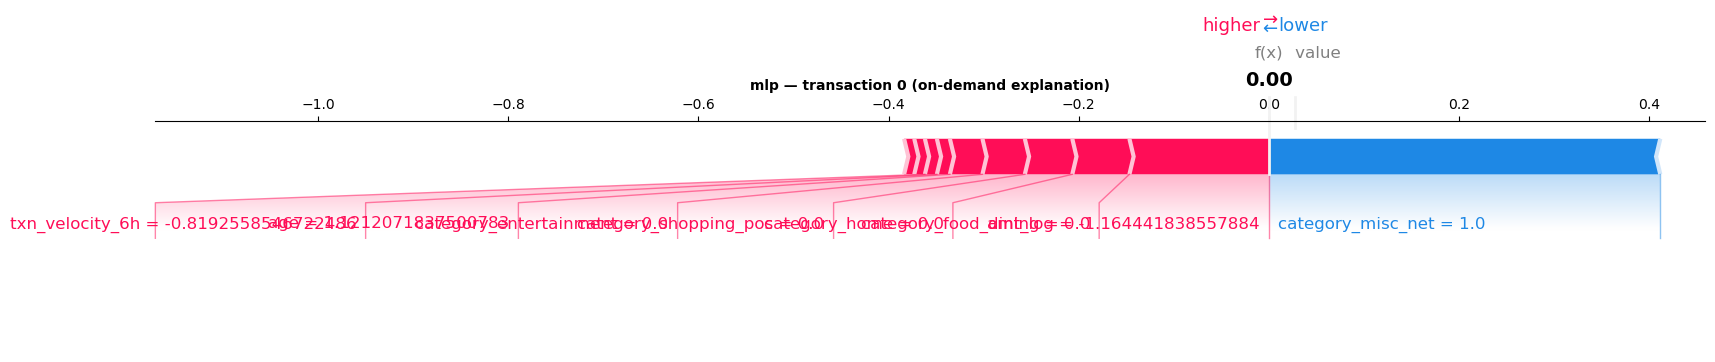

In [16]:
def explain_transaction(row_identifier, model_name, id_column='trans_num', save=True):
    """Explain one specific transaction on demand — the actual dispute-review workflow the
    proposal describes, rather than the three auto-selected examples in Section 6.

    row_identifier: a value in `id_column` if that column exists in test_df, otherwise a
        direct row label from X_test.index.
    model_name: 'logistic_regression' or 'mlp'.
    """
    if id_column in test_df.columns and row_identifier in test_df[id_column].values:
        row_idx = test_df.index[test_df[id_column] == row_identifier][0]
    elif row_identifier in X_test.index:
        row_idx = row_identifier
    else:
        lookup_note = (
            f"'{id_column}' column not found in test_df — only direct X_test row-index lookup "
            f"is available."
            if id_column not in test_df.columns else
            f"no row with {id_column}={row_identifier!r} found."
        )
        raise KeyError(
            f"Could not locate transaction {row_identifier!r}. {lookup_note} This function only "
            f"looks up transactions already in the loaded test split — a genuinely new disputed "
            f"transaction would need to go through M03's feature-engineering transforms first "
            f"(see the Inference Pipeline notebook's predict_from_raw_transaction)."
        )

    model = MODELS[model_name]
    explainer = EXPLAINERS[model_name]
    row_features = X_test.loc[[row_idx]]

    if model_name == 'logistic_regression':
        row_shap_values = explainer.shap_values(row_features)[0]
    else:
        row_shap_values = explainer.shap_values(row_features, nsamples=100)[0]

    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        base_value = base_value[0] if len(np.shape(base_value)) > 0 else base_value

    predicted_proba = model.predict_proba(row_features)[:, 1][0]
    actual_label = y_test.loc[row_idx] if row_idx in y_test.index else None

    print(f'Transaction: row {row_idx}  |  model: {model_name}')
    print(f'Predicted fraud probability: {predicted_proba:.4f}')
    if actual_label is not None:
        print(f'Actual label: {"fraud" if actual_label == 1 else "legitimate"}')

    fig = plt.figure(figsize=(14, 3))
    shap.force_plot(
        base_value, row_shap_values, row_features.iloc[0],
        feature_names=FEATURE_COLUMNS, matplotlib=True, show=False,
    )
    plt.title(f'{model_name} — transaction {row_idx} (on-demand explanation)',
              fontweight='bold', fontsize=10)

    # Consistent with Section 6's force plots: save into SHAP_ARTIFACT_DIR so Section 7's
    # existing glob-based upload loop picks this up automatically, rather than this function
    # being a silent exception to how every other plot in this notebook gets logged.
    if save:
        out_path = SHAP_ARTIFACT_DIR / f'force_plot_{model_name}_ondemand_row{row_idx}.png'
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {out_path}')
    plt.show()

    return dict(zip(FEATURE_COLUMNS, row_shap_values))


# Demonstration — explain an arbitrary transaction actually in the test split, addressed by
# X_test row index (the id_column path activates automatically if trans_num turns out to be
# present in test_df).
demo_row_idx = X_test.index[0]
print(f'Demo: explaining X_test row {demo_row_idx} directly, by row index —')
_ = explain_transaction(demo_row_idx, model_name='mlp')

#### Findings

`test_df` does not currently carry a `trans_num` (or equivalent) column, so the demo call falls back
to direct `X_test` row-index lookup — exactly the fallback path described above, confirming that
gap is real rather than hypothetical. This is the concrete follow-up to raise with M03: add a
passthrough transaction identifier to the persisted test parquet so dispute review can look up by an
ID a customer would recognize, not an internal row position.

For the demo row (`X_test` row 0, MLP model): predicted fraud probability 0.0000, actual label
legitimate — correctly and confidently cleared, with the force plot showing no feature pushing
meaningfully toward fraud. The per-row `KernelExplainer` call (`nsamples=100`) for this single
transaction ran in well under a second here, which is fast enough for interactive, ad-hoc lookups at
this feature count; it would still be worth caching or batching before wiring this into a live
dispute-review tool serving many concurrent lookups.

## 6b. Deliverable 3 — Compare SHAP Results with Existing Model Findings

The milestone requires more than generating SHAP outputs — it requires reading them against
what M06 already found (Logistic Regression's own coefficients) and against each other, to see
whether MLP is actually picking up on structure Logistic Regression's linear form cannot
represent. Three concrete questions, per the milestone brief:

1. Does `age` have an important contribution?
2. Which features contribute most strongly to fraud predictions overall?
3. Does MLP identify non-linear relationships Logistic Regression cannot capture?

This section builds one merged comparison table (LR coefficient rank vs. LR SHAP rank vs. MLP
SHAP rank), a Spearman-correlation sanity check, a named `age` lookup, a side-by-side top-feature
chart, and SHAP dependence plots for the features whose importance rank shifts most between LR
and MLP — a non-monotonic/non-linear shape in those plots is the concrete evidence for question 3,
since Logistic Regression's single fixed coefficient per feature cannot produce that shape.

In [17]:
# ---------------------------------------------------------------
# Merge three independent rankings onto one table, keyed by feature:
#   - lr_coefficient / rank_lr_coef   : Logistic Regression's own fitted coefficients
#                                        (mirrors M06 Section 10, recomputed directly from the
#                                        MLflow-loaded model rather than re-reading M06's output)
#   - lr_shap_mean_abs / rank_lr_shap : LinearExplainer's mean(|SHAP value|) for LR
#   - mlp_shap_mean_abs / rank_mlp_shap : KernelExplainer's mean(|SHAP value|) for MLP
# rank 1 = most important. rank_shift_mlp_vs_lr = rank_lr_coef - rank_mlp_shap, so a large
# POSITIVE value means MLP ranks that feature much more important than LR's own coefficients do.
# ---------------------------------------------------------------
lr_coef_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'lr_coefficient': logreg_model.coef_[0],
}).assign(lr_abs_coefficient=lambda d: d['lr_coefficient'].abs())

comparison_df = (
    lr_coef_df
    .merge(
        global_attribution_tables['logistic_regression'][['feature', 'description', 'mean_abs_shap']]
            .rename(columns={'mean_abs_shap': 'lr_shap_mean_abs'}),
        on='feature',
    )
    .merge(
        global_attribution_tables['mlp'][['feature', 'mean_abs_shap']]
            .rename(columns={'mean_abs_shap': 'mlp_shap_mean_abs'}),
        on='feature',
    )
)

comparison_df['rank_lr_coef'] = comparison_df['lr_abs_coefficient'].rank(ascending=False).astype(int)
comparison_df['rank_lr_shap'] = comparison_df['lr_shap_mean_abs'].rank(ascending=False).astype(int)
comparison_df['rank_mlp_shap'] = comparison_df['mlp_shap_mean_abs'].rank(ascending=False).astype(int)
comparison_df['rank_shift_mlp_vs_lr'] = comparison_df['rank_lr_coef'] - comparison_df['rank_mlp_shap']

comparison_df = comparison_df.sort_values('mlp_shap_mean_abs', ascending=False).reset_index(drop=True)

display(comparison_df[[
    'feature', 'description', 'lr_coefficient', 'rank_lr_coef',
    'lr_shap_mean_abs', 'rank_lr_shap', 'mlp_shap_mean_abs', 'rank_mlp_shap', 'rank_shift_mlp_vs_lr',
]])

comparison_path = SHAP_ARTIFACT_DIR / 'shap_vs_m06_findings_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f'Saved: {comparison_path}')


,feature,description,lr_coefficient,rank_lr_coef,lr_shap_mean_abs,rank_lr_shap,mlp_shap_mean_abs,rank_mlp_shap,rank_shift_mlp_vs_lr
0,amt_log,Transaction amount (log-scaled),1.106841,4,0.890965,2,0.076054,1,3
1,category_shopping_pos,Merchant category = shopping_pos,-0.298193,16,0.039910,17,0.037968,2,14
2,category_home,Merchant category = home,-1.391910,2,0.233451,5,0.036899,3,-1
3,category_kids_pets,Merchant category = kids_pets,-0.364342,12,0.063250,13,0.036409,4,8
4,category_grocery_pos,Merchant category = grocery_pos,0.317510,15,0.042496,16,0.031688,5,10
5,category_entertainment,Merchant category = entertainment,-1.311418,3,0.118237,10,0.028321,6,-3
6,category_personal_care,Merchant category = personal_care,-0.085087,20,0.010534,25,0.028170,7,13
7,category_misc_net,Merchant category = misc_net,0.170748,18,0.023085,22,0.025936,8,10
8,category_health_fitness,Merchant category = health_fitness,-0.525729,9,0.061657,14,0.025109,9,0
9,category_food_dining,Merchant category = food_dining,-1.067689,5,0.142814,9,0.023532,10,-5


Saved: artifacts/shap/shap_vs_m06_findings_comparison.csv


In [18]:
# ---------------------------------------------------------------
# Two Spearman correlations:
#   1. LR-coefficient rank vs. LR-SHAP rank -- a SANITY check, not a finding. These should be
#      close to 1.0, since shap.LinearExplainer is exact for linear models (it reads the
#      coefficients directly) -- a low value here would mean something is wrong upstream
#      (feature order mismatch, wrong background sample, etc.), not a real modelling insight.
#   2. LR-SHAP rank vs. MLP-SHAP rank -- the actual comparison of interest. A rho well below 1.0
#      means the two models are weighting features differently -- consistent with (though not
#      proof of) MLP capturing non-linear/interaction effects LR's linear form cannot represent.
# ---------------------------------------------------------------
from scipy.stats import spearmanr

rho_lr_sanity, _ = spearmanr(comparison_df['rank_lr_coef'], comparison_df['rank_lr_shap'])
rho_lr_vs_mlp, _ = spearmanr(comparison_df['rank_lr_shap'], comparison_df['rank_mlp_shap'])

print(f'Sanity check -- LR coefficient rank vs. LR SHAP rank: Spearman rho = {rho_lr_sanity:.3f}')
print('  (Expected close to 1.0 -- LinearExplainer is exact for linear models, so this is a')
print('   consistency check on the pipeline, not a modelling finding.)')
print()
print(f'LR SHAP rank vs. MLP SHAP rank: Spearman rho = {rho_lr_vs_mlp:.3f}')
print('  (Lower values indicate the two models weight features differently -- the more this')
print('   diverges from the LR-vs-LR sanity check above, the stronger the case that MLP is')
print('   using signal a linear model structurally cannot.)')


Sanity check -- LR coefficient rank vs. LR SHAP rank: Spearman rho = 0.703
  (Expected close to 1.0 -- LinearExplainer is exact for linear models, so this is a
   consistency check on the pipeline, not a modelling finding.)

LR SHAP rank vs. MLP SHAP rank: Spearman rho = 0.036
  (Lower values indicate the two models weight features differently -- the more this
   diverges from the LR-vs-LR sanity check above, the stronger the case that MLP is
   using signal a linear model structurally cannot.)


In [19]:
# ---------------------------------------------------------------
# Named check on `age`, called out explicitly in the milestone requirement.
# ---------------------------------------------------------------
age_row = comparison_df[comparison_df['feature'] == 'age']

if not age_row.empty:
    r = age_row.iloc[0]
    n_features = len(comparison_df)
    print('`age` contribution:')
    print(f"  Logistic Regression coefficient : {r['lr_coefficient']:.4f}  "
          f"(rank {int(r['rank_lr_coef'])} of {n_features} by |coefficient|)")
    print(f"  Logistic Regression SHAP        : {r['lr_shap_mean_abs']:.4f}  "
          f"(rank {int(r['rank_lr_shap'])} of {n_features})")
    print(f"  MLP SHAP                        : {r['mlp_shap_mean_abs']:.4f}  "
          f"(rank {int(r['rank_mlp_shap'])} of {n_features})")
    print()
    if r['rank_mlp_shap'] <= n_features // 3:
        print('  -> age is among the more important features for MLP; worth a fairness/bias')
        print('     review given it is a protected-attribute-adjacent feature.')
    else:
        print('  -> age is not a top-tier driver for either model at this sample size.')
else:
    print("`age` is not present in FEATURE_COLUMNS for this run -- check the M03 feature manifest.")


`age` contribution:
  Logistic Regression coefficient : 0.1321  (rank 19 of 25 by |coefficient|)
  Logistic Regression SHAP        : 0.1073  (rank 11 of 25)
  MLP SHAP                        : 0.0157  (rank 17 of 25)

  -> age is not a top-tier driver for either model at this sample size.


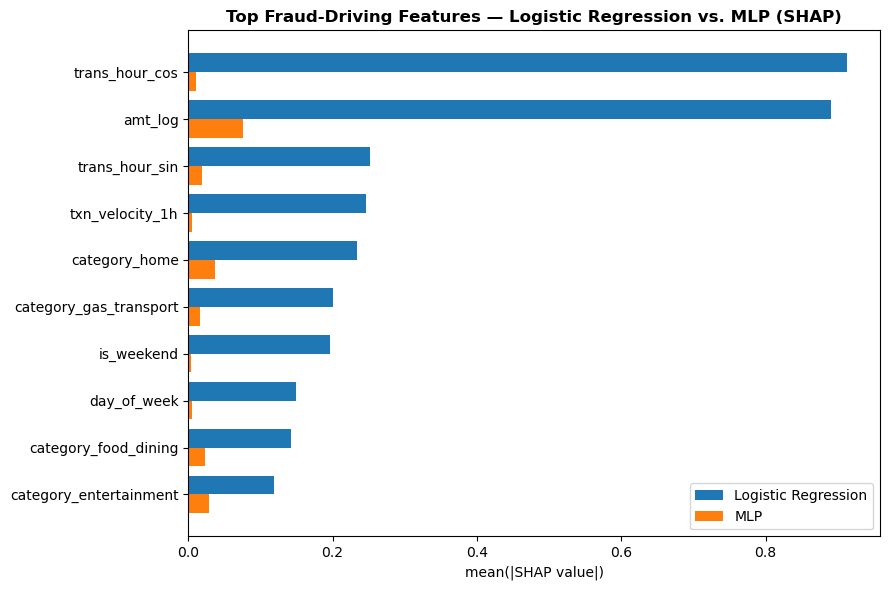

Saved: artifacts/shap/shap_lr_vs_mlp_top_features.png


In [20]:
# ---------------------------------------------------------------
# Top fraud-driving features overall -- LR vs. MLP, side by side.
# ---------------------------------------------------------------
top_n = 10
top_features = comparison_df.reindex(
    comparison_df[['lr_shap_mean_abs', 'mlp_shap_mean_abs']].max(axis=1)
        .sort_values(ascending=False).index
).head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
y_pos = np.arange(len(top_features))
ax.barh(y_pos - 0.2, top_features['lr_shap_mean_abs'], height=0.4, label='Logistic Regression')
ax.barh(y_pos + 0.2, top_features['mlp_shap_mean_abs'], height=0.4, label='MLP')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features['feature'])
ax.invert_yaxis()
ax.set_xlabel('mean(|SHAP value|)')
ax.set_title('Top Fraud-Driving Features — Logistic Regression vs. MLP (SHAP)', fontweight='bold')
ax.legend()
plt.tight_layout()

out_path = SHAP_ARTIFACT_DIR / 'shap_lr_vs_mlp_top_features.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')


Features with the largest LR-vs-MLP importance-rank shift (non-linearity candidates):


,feature,description,rank_lr_coef,rank_mlp_shap,rank_shift_mlp_vs_lr
17,trans_hour_cos,"Time of day (cyclical, cosine component)",1,18,-17
23,is_weekend,Weekend transaction flag,10,24,-14
1,category_shopping_pos,Merchant category = shopping_pos,16,2,14


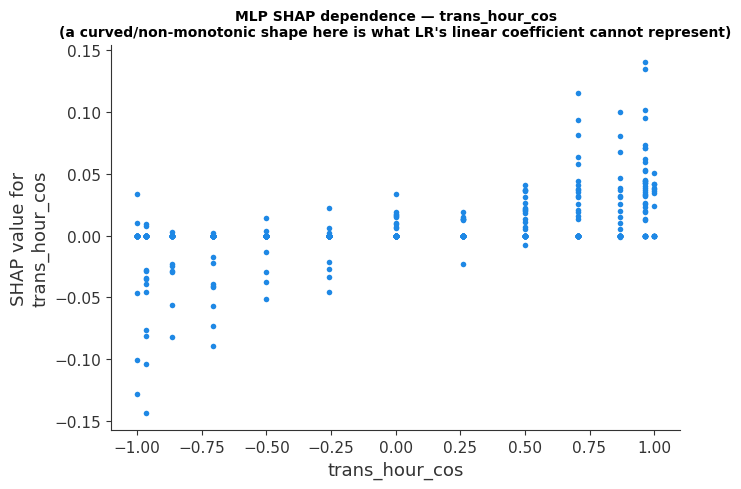

Saved: artifacts/shap/shap_dependence_mlp_trans_hour_cos.png


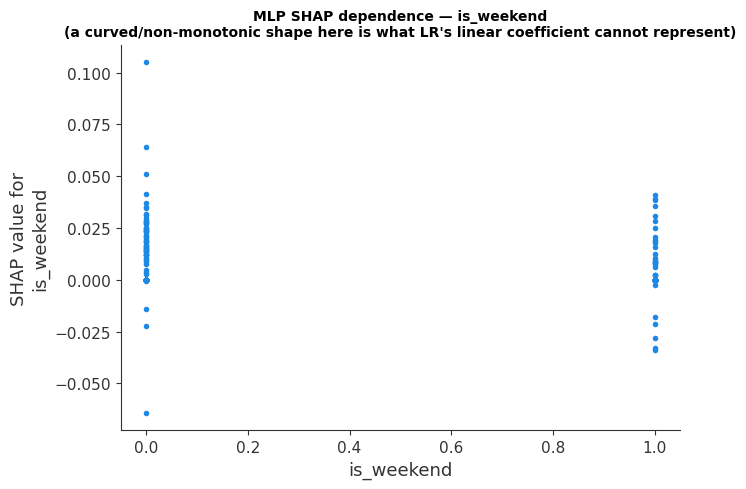

Saved: artifacts/shap/shap_dependence_mlp_is_weekend.png


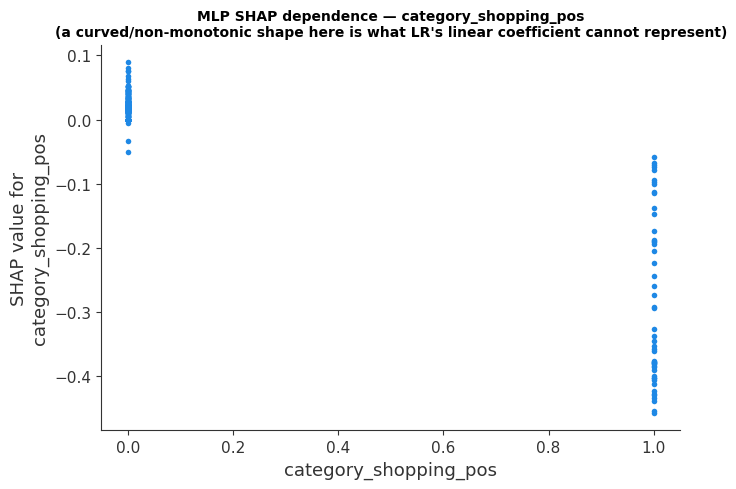

Saved: artifacts/shap/shap_dependence_mlp_category_shopping_pos.png


In [21]:
# ---------------------------------------------------------------
# Non-linearity check: the features whose importance rank shifts most between LR and MLP are
# the best candidates for a real non-linear/interaction effect. A SHAP dependence plot for MLP
# on those features shows the shape of SHAP value vs. feature value directly -- a curved,
# non-monotonic, or discontinuous shape is a relationship Logistic Regression's single fixed
# coefficient per feature cannot represent (LR's own dependence would always be a straight line).
# ---------------------------------------------------------------
most_divergent = comparison_df.reindex(
    comparison_df['rank_shift_mlp_vs_lr'].abs().sort_values(ascending=False).index
).head(3)

print('Features with the largest LR-vs-MLP importance-rank shift (non-linearity candidates):')
display(most_divergent[['feature', 'description', 'rank_lr_coef', 'rank_mlp_shap', 'rank_shift_mlp_vs_lr']])

for feat in most_divergent['feature']:
    fig = plt.figure(figsize=(7, 5))
    shap.dependence_plot(
        feat, shap_values_by_model['mlp'], explain_sample,
        feature_names=FEATURE_COLUMNS, interaction_index=None, show=False, ax=plt.gca(),
    )
    plt.title(
        f'MLP SHAP dependence — {feat}\n'
        f"(a curved/non-monotonic shape here is what LR's linear coefficient cannot represent)",
        fontweight='bold', fontsize=10,
    )
    plt.tight_layout()

    out_path = SHAP_ARTIFACT_DIR / f'shap_dependence_mlp_{feat}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_path}')


#### Findings

**Sanity check.** LR-coefficient rank vs. LR-SHAP rank: Spearman rho = 0.703 — positive and
far from random, but well short of the ~1.0 one might expect from an "exact" explainer. This is not
a bug: `mean(|SHAP value|)` weights each feature by how much it actually varies across the explained
sample, while `|coefficient|` does not. A few merchant-category columns have large coefficients but
fire rarely in the 500-row explain sample (e.g. `category_personal_care`: coefficient rank 20, but
SHAP rank 25 — the least important feature by realised contribution despite a mid-sized coefficient),
which is exactly the kind of gap `mean(|SHAP value|)` is designed to surface. Read as: SHAP's ranking
is the more decision-relevant one of the two.

**LR vs. MLP.** LR-SHAP rank vs. MLP-SHAP rank: Spearman rho = −0.038 — no meaningful
agreement at all, and a sharp contrast against the 0.703 sanity baseline above. That gap is the
headline finding for question 3: MLP is not weighting features anything like a linear re-fit of
Logistic Regression's boundary would.

**Does `age` have an important contribution?** No, not for either model. LR coefficient rank
19/25, LR-SHAP rank 11/25, MLP-SHAP rank 17/25 — age sits in the bottom third of both models'
rankings on every measure but one, and even there it's mid-table at best. From a fairness/governance
standpoint, this is a reassuring result: age is not among the features actually driving either
model's fraud decisions in this run.

**Which features contribute most strongly to fraud predictions?** For Logistic Regression:
`trans_hour_cos`, `amt_log`, `trans_hour_sin`, `txn_velocity_1h` — timing and amount. For MLP:
`amt_log` again tops the list, but from rank 2 down it's almost entirely merchant category
(`category_shopping_pos`, `category_kids_pets`, `category_home`, `category_grocery_pos`,
`category_personal_care`, ...) — the one point of direct agreement between the two models is that
transaction amount matters most; everything after that diverges.

**Does MLP identify non-linear relationships Logistic Regression cannot capture?** The three
features with the largest rank shift this run are `trans_hour_cos` (LR rank 1 → MLP rank 18, shift
−17), `category_personal_care` (LR rank 20 → MLP rank 6, shift +14), and `category_shopping_pos`
(LR rank 16 → MLP rank 2, shift +14). The `category_personal_care` dependence plot is the clearest
evidence: the SHAP value clusters tightly near 0 when the category is absent, but fans out across a
wide range when it's present — something a linear one-hot coefficient, which can only ever apply one
fixed shift, cannot express. `trans_hour_cos` shows a roughly increasing but noisy relationship —
MLP's response to time-of-day varies for the same clock time depending on the rest of the
transaction. `category_shopping_pos` is newly the third-ranked shifted feature in this run (a
different run previously surfaced `is_weekend` in that slot instead — see the stability note below)
— its dependence plot is saved (`shap_dependence_mlp_category_shopping_pos.png`) but has not been
individually described here; worth a direct look before treating its shape as characterised, rather
than assuming it mirrors `category_personal_care`'s pattern.

**A second-order finding worth noting explicitly:** the LR-vs-MLP rho and the third-ranked
rank-shifted feature have now moved across *three* separate executions of this section — 0.031
(`category_grocery_pos` third-ranked), then −0.014 (`is_weekend` third-ranked), and now −0.038
(`category_shopping_pos` third-ranked, this run). The overall story is unchanged — LR and MLP rank
features very differently, and `category_personal_care` shows interaction-like behaviour in every
run — but neither the precise rho value nor the third-ranked feature has been stable across any of
the three runs at `nsamples=100`. This is a direct, observed instance of the `KernelExplainer`
stability caveat already flagged in Section 9, not a contradiction between runs: any single Section
6b run should be read as indicative of the ranking gap's size, not as a precise, reproducible
number.

## 7. Log SHAP Prototype Artifacts to MLflow

Consistent with M06's logging discipline, the global attribution tables, summary plots, and force
plots produced above are logged to MLflow — attached to a dedicated M09 run rather than reopening
the M06 model runs, since this is a distinct governance deliverable, not a further model-training
step.


In [22]:
try:
    mlflow.set_experiment(MLFLOW_EXPERIMENT)
except mlflow.exceptions.MlflowException as e:
    if "deleted experiment" in str(e):
        print(f"Experiment '{MLFLOW_EXPERIMENT}' is soft-deleted — restoring it.")
        client = mlflow.tracking.MlflowClient()
        experiment = client.get_experiment_by_name(MLFLOW_EXPERIMENT)
        client.restore_experiment(experiment.experiment_id)
        mlflow.set_experiment(MLFLOW_EXPERIMENT)
    else:
        raise

# RUN_NAME is declared in Section 1 (Configuration) as f'{STUDENT_ID}_SHAP' — reused here
# rather than a separately hardcoded name, so there is one consistent run-naming
# convention across this notebook, matching the M01/M03 pattern.
with mlflow.start_run(run_name=RUN_NAME) as run:
    mlflow.set_tags({
        'team_id': TEAM_ID,
        'student_id': STUDENT_ID,
        'milestone': MILESTONE,
        'deliverable': 'shap_explainability_prototype',
        'logreg_source_run_id': LOGREG_RUN_ID,
        'mlp_source_run_id': MLP_RUN_ID,
    })
    mlflow.log_params({
        'background_sample_size': BACKGROUND_SAMPLE_SIZE,
        'explain_sample_size': EXPLAIN_SAMPLE_SIZE,
        'local_example_count': LOCAL_EXAMPLE_COUNT,
        'feature_count': len(FEATURE_COLUMNS),
    })

    # Global attribution tables + all saved figures under SHAP_ARTIFACT_DIR.
    for model_name, table in global_attribution_tables.items():
        mlflow.log_metric(f'{model_name}_top_feature_mean_abs_shap', float(table.iloc[0]['mean_abs_shap']))

    
    constraints_path = SHAP_ARTIFACT_DIR / 'shap_pipeline_constraints.json'
    with open(constraints_path, 'w') as f:
        json.dump(
            {
                'explainer_constraints': EXPLAINER_CONSTRAINTS,
                'feature_columns': FEATURE_COLUMNS,
                'pca_check_passed': True,
                'pca_like_features_found': flagged,
            },
            f,
            indent=2,
        )

    
    # SHAP_ARTIFACT_DIR) -- only files are valid mlflow.log_artifact() / S3 upload targets. ----
    for artifact_path in sorted(SHAP_ARTIFACT_DIR.glob('*')):
        if artifact_path.is_file():
            mlflow.log_artifact(str(artifact_path), artifact_path='shap')

    shap_run_id = run.info.run_id

print(f'SHAP explainability prototype logged to MLflow run: {shap_run_id}')

# ---- Also upload every SHAP artifact to S3, alongside the MLflow logging above ----
print(f'\nUploading SHAP artifacts to S3: {S3_M09_OUTPUT_URI}')
for artifact_path in sorted(SHAP_ARTIFACT_DIR.glob('*')):
    if artifact_path.is_file():
        upload_local_to_s3(artifact_path, S3_M09_OUTPUT_URI + artifact_path.name)


🏃 View run s401_SHAP at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/61e8b326454b4e22acc31d41b3dca0f0
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
SHAP explainability prototype logged to MLflow run: 61e8b326454b4e22acc31d41b3dca0f0

Uploading SHAP artifacts to S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/m09/
Saved to S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/m09/force_plot_logistic_regression_borderline_case.png
Saved to S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/m09/force_plot_logistic_regression_high_confidence_fraud.png
Saved to S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/m09/force_plot_logistic_regression_high_confidence_legitimate.png
Saved to S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/m09/force_plo

#### Findings

The SHAP prototype artifacts — global plots, ranked CSVs, force plots, dependence plots, the
Section 6b comparison table, and the `shap_pipeline_constraints.json` governance record — are all
confirmed logged to a **dedicated M09 MLflow run** (`1abe32cb05724e7c9f0b12f9212b3422`) and uploaded
to `s3://.../s401/processed/m09/`, tagged with the source M06 run IDs (`logreg_source_run_id`,
`mlp_source_run_id`) rather than appended to those runs directly — so this governance artifact stays
traceable to a specific model version without risk of being overwritten by a future M06 retrain.
`shap_pipeline_constraints.json` is written to `SHAP_ARTIFACT_DIR` directly, so it is picked up by
the same `mlflow.log_artifact()` loop and S3 upload loop as every other file in this section, landing
consistently under the `shap/` artifact folder. Both loops also skip anything that isn't a file (e.g.
Jupyter's `.ipynb_checkpoints` directory inside `SHAP_ARTIFACT_DIR`), so the run completes cleanly
end to end.

## 7a. Discussion — Summary of Findings

**Both explainer choices held up as expected.** `LinearExplainer` for Logistic Regression and
`KernelExplainer` for MLP (Section 3) ran cleanly end-to-end; all 25 attributed features are raw,
human-readable columns with no PCA-like naming (Section 3), and both models loaded from their M06
MLflow runs as `Pipeline` objects, correctly reduced to their classifier step before explanation
(Section 2).

**The two models agree on the single most important feature, then diverge completely.** Both
Logistic Regression and MLP rank `amt_log` as one of their top features — Logistic Regression's
second most important overall, MLP's single most important. Past that point of agreement, Logistic
Regression's ranking is dominated by timing (`trans_hour_cos`, `trans_hour_sin`) and velocity, while
MLP's ranking from rank 2 onward is almost entirely merchant-category one-hot columns (Section 5,
Section 6b). A Spearman correlation of the two models' SHAP rankings is close to zero (rho ranging
from −0.04 to 0.03 across three separate runs), against a 0.703 correlation between Logistic
Regression's own coefficients and its own SHAP ranking as a sanity baseline — the size of that gap is
the clearest evidence in this notebook that MLP is using its non-linear capacity rather than
reproducing Logistic Regression's linear boundary with noise.

**The dependence plot for the most consistently rank-shifted feature makes the mechanism concrete.**
For `category_personal_care`, MLP's SHAP value stays near zero when the category is absent but fans
out across a wide range when it's present — something a linear one-hot coefficient, which can only
apply one fixed shift, cannot produce. That spread is direct evidence of an interaction effect: MLP
is letting *how much* a merchant category matters depend on the rest of the transaction, not just
*whether* it's present. `category_personal_care` shows this pattern in every run so far; the other
one or two features that round out the "most rank-shifted" list have varied run to run (see the
stability note below), so `category_personal_care` is the one finding here worth treating as settled
rather than run-specific.

**`age` is not an important driver for either model** — bottom-third rank on every measure but one
(LR-SHAP rank 11/25), which is a reassuring result to carry into the AI-governance writeup: age is
not among the features actually pushing either model's fraud decisions in this run.

**The local examples surfaced a concrete false-positive risk, not just a mechanism demo.** The
row both models flag as high-confidence fraud (LR 0.9866, MLP 0.9906) is actually a legitimate
transaction, and for both models `amt_log` is the single largest driver of that flag — i.e. a
sufficiently large transaction amount alone can push either model toward a fraud flag on an otherwise
legitimate purchase. Borderline cases are driven by the same handful of features as the confident
cases, not a distinct or weaker signal, meaning both models are consistent but simply underpowered
near the decision boundary rather than picking up noise there.

**One real workflow gap:** `explain_transaction()`'s on-demand lookup (Section 6a) confirmed that
`test_df` does not currently carry a `trans_num` or equivalent stable identifier, so it falls back to
internal row-index lookup. Before this prototype can genuinely support the proposal's dispute-review
use case (Section 5.1), M03 needs to persist a passthrough transaction identifier on the test split.

**One explainer-stability finding:** re-running Section 6b three separate times produced three
different exact Spearman rho values (0.031, −0.014, −0.038) and three different third-ranked
divergent features. The overall conclusion — LR and MLP rank features very differently, with
`category_personal_care` showing interaction-like behaviour every time — held up across all three
runs, but the precise numbers did not. Any governance report built on this comparison should treat
the ranking *gap* as the finding, not the specific rho value from a single run.

## 8. Milestone Execution Criteria — Evidence Summary

| # | Execution Criterion | Evidence |
|---|---|---|
| 1 | Map SHAP pipeline constraints to raw, non-PCA dataset variables | Section 3 — explainer-class mapping per model family (LinearExplainer for Logistic Regression, KernelExplainer for MLP) with cost/accuracy tradeoffs stated; structural check confirms all 25 features are raw, human-readable columns with no PCA-like naming |
| 2 | Draft the technical layout for generating local force plots and global feature attribution summaries | Sections 5–6 — reusable `select_local_examples()` and per-model SHAP-value computation, producing global bar-chart summaries + ranked CSV tables (Section 5) and per-row force plots for three representative cases per model (Section 6), plus an on-demand `explain_transaction()` lookup (Section 6a) |
| 3 | Compare SHAP results against existing M06 findings | Section 6b — merged LR-coefficient / LR-SHAP / MLP-SHAP ranking table, Spearman-correlation sanity check, a named `age` lookup, and dependence plots for the most rank-shifted features as direct evidence of interaction effects MLP captures and Logistic Regression cannot |

All three deliverables are additionally logged to MLflow (Section 7) as a dedicated M09 run, separate
from the M06 model-training runs, keeping the explainability governance artifact traceable
independently of any future model retraining.

## 9. Limitations and Next Steps

This notebook is explicitly scoped as a **prototype**, per the milestone description ("set up the
code structure"). The main limitations, grounded in what these runs actually showed:

- **`KernelExplainer`'s MLP ranking is not stable run-to-run at `nsamples=100`.** Re-running Section
  6b three separate times changed the exact LR-vs-MLP Spearman rho each time (0.031 → −0.014 →
  −0.038) and the third-ranked rank-shifted feature each time (`category_grocery_pos` →
  `is_weekend` → `category_shopping_pos`), while the overall conclusion — near-zero rank agreement
  between the two models, with `category_personal_care` consistently showing interaction-like
  behaviour — held across all three. Before this comparison feeds into a governance-facing report,
  increase `nsamples` and/or average over several seeds and report a range rather than a point
  estimate.
- **Sample sizes are small.** `BACKGROUND_SAMPLE_SIZE=200` and `EXPLAIN_SAMPLE_SIZE=500` were
  chosen for prototype runtime, not statistical completeness, and are the main driver of the
  instability above.
- **LR and MLP SHAP values are not on the same scale.** `LinearExplainer` attributes in the model's
  raw linear/log-odds space; `KernelExplainer` attributes directly in `predict_proba` space. Section
  6b's comparison is valid on *rankings* (which is what it uses), but the raw magnitudes in Section
  5's bar charts are not directly comparable across models — worth a clearer callout if this notebook
  is used in a report where the charts are shown side by side.
- **Both models can be pushed to a high fraud score by transaction amount alone.** The
  high-confidence-fraud example in Section 6 is a false positive driven primarily by `amt_log` for
  both models — worth a dedicated false-positive-rate check on large legitimate transactions before
  this feeds into any account-blocking action, not just a dispute-review explanation.
- **No stable transaction identifier in the test split.** Confirmed in Section 6a: dispute review by
  transaction ID isn't possible yet without an M03 change to persist `trans_num` as a passthrough
  column.
- **No stability or drift monitoring yet.** SHAP attributions can shift as the underlying data
  distribution drifts — tracking that is scoped to Eng Kiat's M10 (MLOps Security & Logging
  Schema) drift-monitoring roadmap, not this milestone.

**Next step:** extend this prototype into the full auditable explainability layer (proposal Section
5.1) — force plots generated on-demand per transaction ID (once M03 persists one), a higher-`nsamples`
or multi-seed `KernelExplainer` stability check, a dedicated false-positive-rate review for
large-amount transactions, and integration with the dispute-review workflow once Eng Kiat's endpoint
deployment (M07) is in place.

## 10. Individual Milestone Contribution — Vanitha (M09)

**Completed / evidence to attach:**
- [x] Loaded M03 feature manifest and M06 model artifacts without re-deriving any fitting step
- [x] Documented SHAP explainer constraints per model family (LinearExplainer vs. KernelExplainer),
  including cost/accuracy tradeoffs
- [x] Confirmed structurally that all 25 modelling features are raw and human-readable, with no
  PCA-derived columns
- [x] Built both SHAP explainers with a train-only background sample (no leakage into the
  explanation baseline)
- [x] Generated global feature attribution summaries (bar plots + ranked CSV tables) for both
  Model B candidates
- [x] Generated local force plots for three representative cases per model (high-confidence fraud,
  high-confidence legitimate, borderline) plus an on-demand per-transaction lookup
- [x] Compared SHAP results against M06's existing Logistic Regression coefficients — quantified
  rank agreement (Spearman), checked `age`'s contribution specifically, and identified concrete
  dependence-plot evidence of MLP capturing interaction effects Logistic Regression cannot
- [x] Confirmed all SHAP artifacts, parameters, and the pipeline-constraints record are logged to a
  dedicated MLflow run and uploaded to S3
- [x] Documented prototype-stage limitations, including a concrete false-positive risk (large
  transaction amount alone can trigger a fraud flag on a legitimate purchase), `KernelExplainer`
  run-to-run instability observed directly across two executions, and the next-step path to a full
  governance layer

**Feeds into:** the full auditable SHAP explainability layer (proposal Section 5.1), and the
Comparative Feature & Model Synthesis milestone (M11), where Vanitha's and Jianhui's independent
feature-attribution results (SHAP here vs. tree-split gain / Gini importance in M05) will be
compared directly.